In [1]:
%%time
import sys, os
path_dir = os.getcwd()
sys.path.append(path_dir+"/Functions")
from General_functions import *
from Input_func import *
from IO_Plots import *
from PC_Plots import *
from DCN_Plots import *
from New_func import *
from read_data import *
start_scope()
###################################################################
######################### Load Parameters #########################
###################################################################
Name = "No_BCM"
time_now = "16:43"
date = "06-06"#datetime.datetime.now().strftime("%m-%d")
Frozen_data = sio.loadmat('Data/'+date+'/Frozen.mat', squeeze_me=True)
Output_Noise,Output_Noise_Extended,Output_PC,Output_DCN,Output_IO,Output_mon_N_PC,Output_Noise_Coupled,Output_Noise_Extended_Coupled,Output_PC_Coupled,Output_DCN_Coupled,Output_IO_Coupled,Output_mon_N_PC_Coupled = load_data(Name,time_now,date)
Params, Noise_frozen, Values, Synapses = Read_Input(Frozen_data)
###################################################################
########################### Load Cells ############################
###################################################################
Noise, Noise_Extended, PC, DCN, IO, mon_N_PC = Output_func(Name,"",Output_Noise,Output_Noise_Extended,Output_PC,Output_DCN,Output_IO,Output_mon_N_PC,Output_Noise_Coupled,Output_Noise_Extended_Coupled,Output_PC_Coupled,Output_DCN_Coupled,Output_IO_Coupled,Output_mon_N_PC_Coupled)
Noise_Coupled, Noise_Extended_Coupled, PC_Coupled, DCN_Coupled, IO_Coupled, mon_N_PC_Coupled = Output_func(Name,"Coupled",Output_Noise,Output_Noise_Extended,Output_PC,Output_DCN,Output_IO,Output_mon_N_PC,Output_Noise_Coupled,Output_Noise_Extended_Coupled,Output_PC_Coupled,Output_DCN_Coupled,Output_IO_Coupled,Output_mon_N_PC_Coupled)
time_x = Noise.t

step1 = 400
step = int(step1/(Params.dt_rec/msecond))
xx = range(-step,step)
xx1 = [item * (Params.dt_rec/msecond) for item in xx]
half = int(time_x[len(time_x)//2]/1000)

CPU times: user 1.51 s, sys: 807 ms, total: 2.31 s
Wall time: 3.17 s


In [2]:
%%time
PC_new_learned = New_PC_learned(Params,PC)
PC_new_learned_Coupled = New_PC_learned(Params,PC_Coupled)
PC_new = New_PC(Params,PC)
PC_new_Coupled = New_PC(Params,PC_Coupled)

CPU times: user 938 ms, sys: 6.58 ms, total: 945 ms
Wall time: 946 ms


In [3]:
# def raster_plot(learned,step1,Params,IO,PC):
#     for ii in range(0,Params.N_Cells_PC):
#         plt.figure(figsize=(7, 5), dpi= 80, facecolor='w', edgecolor='k')
#         jj = Synapses.IO_PC_Synapse_Sources[ii]
#         if learned == "Learned":
#             PC_all = PC.Spikemon_Cells[ii][len(PC.Spikemon_Cells[ii])//2:]
#             IO_all = IO.Spikemon_Cells[jj][len(IO.Spikemon_Cells[jj])//2:]
#         else:
#             PC_all = PC.Spikemon_Cells[ii][:len(PC.Spikemon_Cells[ii])//2]
#             IO_all = IO.Spikemon_Cells[jj][:len(PC.Spikemon_Cells[ii])//2]
#         for kk in range(0,len(IO_all)):
#             start = IO_all[kk]-step1/1000
#             end = IO_all[kk]+step1/1000
#             if start<50:
#                 continue
#             bb = []
#             for ss in range(0,len(PC_all)):
#                 if start<=PC_all[ss]<=end:
#                     bb.append(PC_all[ss])
#                 else:
#                     continue
#             plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black')
#             aa = []
#             for ll in range(0,len(IO_all)):
#                 if start<=IO_all[ll]<=end:
#                     aa.append(IO_all[ll])
#                 else:
#                     continue
#             plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue')
#             plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red')
#         plt.show()



In [4]:
# raster_plot("",step1,Params,IO,PC)

In [5]:
# raster_plot("Learned",step1,Params,IO,PC)

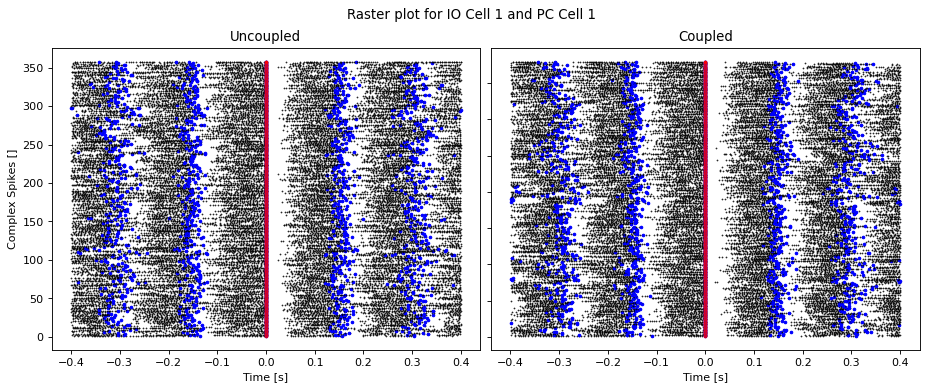

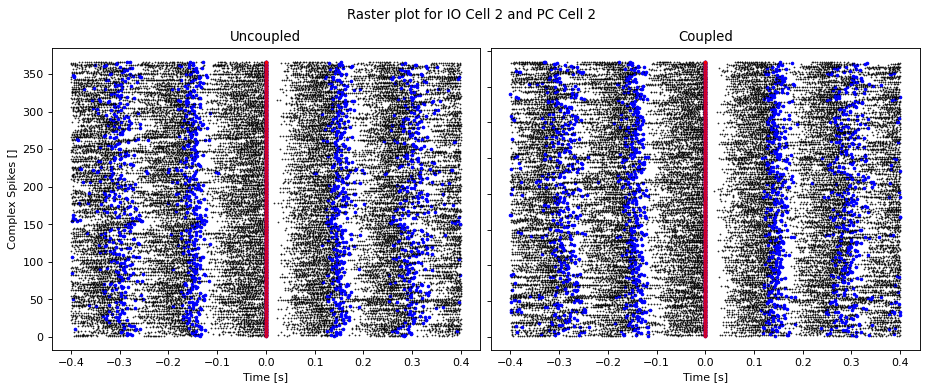

In [6]:
learned = "Learned"
for ii in range(0,Params.N_Cells_PC):
    fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
    gs1 = gridspec.GridSpec(1, 2)
    gs1.update(wspace=0.025, hspace=0.05) # set the spacing between axes. 
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    fig.suptitle('Raster plot for IO Cell '+str(jj+1)+' and PC Cell '+str(ii+1)) # or plt.suptitle('Main title')
    if learned == "Learned":
        PC_all = PC.Spikemon_Cells[ii]#[len(PC.Spikemon_Cells[ii])//2:]
        if size(IO.Spikemon_Cells[jj]) < 2:
            IO_all = [IO.Spikemon_Cells[jj]]
        else:
            IO_all = IO.Spikemon_Cells[jj]#[len(IO.Spikemon_Cells[jj])//2:]
    else:
        PC_all = PC.Spikemon_Cells[ii]#[:len(PC.Spikemon_Cells[ii])//2]
        if size(IO.Spikemon_Cells[jj]) < 2:
            IO_all = [IO.Spikemon_Cells[jj]]
        else:
            IO_all = IO.Spikemon_Cells[jj]#[:len(IO.Spikemon_Cells[ii])//2]
    ax1 = plt.subplot(gs1[0])
    for kk in range(0,size(IO_all)):
        start = IO_all[kk]-step1/1000
        end = IO_all[kk]+step1/1000
        if start<0:
            continue
        bb = []
        for ss in range(0,len(PC_all)):
            if start<=PC_all[ss]<=end:
                bb.append(PC_all[ss])
            else:
                continue
        ax1 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
        aa = []
        for ll in range(0,len(IO_all)):
            if start<=IO_all[ll]<=end:
                aa.append(IO_all[ll])
            else:
                continue
        ax1 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=5)
        ax1 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=5)
    plt.title('Uncoupled')
    ylabel('Complex Spikes []')
    xlabel('Time [s]')
    ax2 = plt.subplot(gs1[1])
    ax2.set_yticklabels([])
    jj = Synapses.IO_PC_Synapse_Sources[ii]
    if learned == "Learned":
        PC_all = PC_Coupled.Spikemon_Cells[ii]#[len(PC.Spikemon_Cells[ii])//2:]
        if size(IO_Coupled.Spikemon_Cells[jj]) < 2:
            IO_all = [IO_Coupled.Spikemon_Cells[jj]]
        else:
            IO_all = IO_Coupled.Spikemon_Cells[jj]#[len(IO.Spikemon_Cells[jj])//2:]
    else:
        PC_all = PC_Coupled.Spikemon_Cells[ii]
        if size(IO_Coupled.Spikemon_Cells[jj]) < 2:
            IO_all = [IO_Coupled.Spikemon_Cells[jj]]
        else:
            IO_all = IO_Coupled.Spikemon_Cells[jj]
    for kk in range(0,size(IO_all)):
        start = IO_all[kk]-step1/1000
        end = IO_all[kk]+step1/1000
        if start<0:
            continue
        bb = []
        for ss in range(0,len(PC_all)):
            if start<=PC_all[ss]<=end:
                bb.append(PC_all[ss])
            else:
                continue
        ax2 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
        aa = []
        for ll in range(0,len(IO_all)):
            if start<=IO_all[ll]<=end:
                aa.append(IO_all[ll])
            else:
                continue
        ax2 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=5)
        ax2 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=5)
    plt.title('Coupled')
    xlabel('Time [s]')   
    plt.show()

In [7]:
# learned = "Learned"
# for ii in range(0,Params.N_Cells_PC):
#     fig = plt.figure(figsize=(14, 5), dpi= 80, facecolor='w', edgecolor='k')
#     gs1 = gridspec.GridSpec(1, 2)
#     gs1.update(wspace=0.025, hspace=0.05) # set the spacing between axes. 
#     jj = Synapses.IO_PC_Synapse_Sources[ii]
#     fig.suptitle('Raster plot for IO Cell '+str(jj+1)+' and PC Cell '+str(ii+1)) # or plt.suptitle('Main title')
#     if learned == "Learned":
#         PC_all = PC.Spikemon_Cells[ii]#[len(PC.Spikemon_Cells[ii])//2:]
#         IO_all = IO.Spikemon_Cells[jj]#[len(IO.Spikemon_Cells[jj])//2:]
#         if size(IO.Spikemon_Cells[jj]) < 2:
#             IO_all = [IO.Spikemon_Cells[jj]]
#     else:
#         PC_all = PC.Spikemon_Cells[ii]#[:len(PC.Spikemon_Cells[ii])//2]
#         IO_all = IO.Spikemon_Cells[jj]#[:len(IO.Spikemon_Cells[ii])//2]
#         if size(IO.Spikemon_Cells[jj]) < 2:
#             IO_all = [IO.Spikemon_Cells[jj]]
#     ax1 = plt.subplot(gs1[0])
#     for kk in range(0,len(IO_all)):
#         start = IO_all[kk]-step1/1000
#         end = IO_all[kk]+step1/1000
#         print(start)
#         print(end)
#         print(IO_all[kk])
#         if learned == "Learned":
#             if start<int(Params.exp_run/second):
#                 continue
#         else:
#             if start>int(Params.exp_run/second):
#                 continue
#         bb = []
#         for ss in range(0,len(PC_all)):
#             print(PC_all[ss])
#             if start<=PC_all[ss]<=end:
#                 bb.append(PC_all[ss])
#             else:
#                 continue
#         ax1 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
#         aa = []
#         for ll in range(0,len(IO_all)):
#             if start<=IO_all[ll]<=end:
#                 aa.append(IO_all[ll])
#             else:
#                 continue
#         ax1 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
#         ax1 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
#     plt.title('Uncoupled')
#     ylabel('Complex Spikes []')
#     xlabel('Time [s]')
#     ax2 = plt.subplot(gs1[1])
#     ax2.set_yticklabels([])
#     jj = Synapses.IO_PC_Synapse_Sources[ii]
#     if learned == "Learned":
#         PC_all = PC_Coupled.Spikemon_Cells[ii]#[len(PC.Spikemon_Cells[ii])//2:]
#         IO_all = IO_Coupled.Spikemon_Cells[jj]#[len(IO.Spikemon_Cells[jj])//2:]
#         if size(IO_Coupled.Spikemon_Cells[jj]) < 2:
#             IO_all = [IO_Coupled.Spikemon_Cells[jj]]
#     else:
#         PC_all = PC_Coupled.Spikemon_Cells[ii]
#         IO_all = IO_Coupled.Spikemon_Cells[jj]
#         if size(IO_Coupled.Spikemon_Cells[jj]) < 2:
#             IO_all = [IO_Coupled.Spikemon_Cells[jj]]
#     for kk in range(0,len(IO_all)):
#         start = IO_all[kk]-step1/1000
#         end = IO_all[kk]+step1/1000
#         if learned == "Learned":
#             if start<int(Params.exp_run/second):
#                 continue
#         else:
#             if start>int(Params.exp_run/second):
#                 continue
#         bb = []
#         for ss in range(0,len(PC_all)):
#             if start<=PC_all[ss]<=end:
#                 bb.append(PC_all[ss])
#             else:
#                 continue
#         ax2 = plt.scatter([x -IO_all[kk] for x in bb],[kk]*len(bb),color='black',s=0.25)
#         aa = []
#         for ll in range(0,len(IO_all)):
#             if start<=IO_all[ll]<=end:
#                 aa.append(IO_all[ll])
#             else:
#                 continue
#         ax2 = plt.scatter([x -IO_all[kk] for x in aa],[kk]*len(aa),color='blue',s=0.75)
#         ax2 = plt.scatter(IO_all[kk]-IO_all[kk],kk,color='red',s=0.75)
#     plt.title('Coupled')
#     xlabel('Time [s]')   
#     plt.show()